In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

os.makedirs("/home/adityaa/Desktop/Mini Project/data", exist_ok=True)
os.makedirs("/home/adityaa/Desktop/Mini Project/data/sales_forecast_images", exist_ok=True)

IMG = "/home/adityaa/Desktop/Mini Project/data/sales_forecast_images/"

print("All libraries imported successfully")

Importing plotly failed. Interactive plots will not work.


All libraries imported successfully


In [2]:
df = pd.read_csv("/home/adityaa/Desktop/Mini Project/data/processed_retail_data.csv", parse_dates=["InvoiceDate"])

print(f"Loaded: {df.shape[0]:,} rows")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
df.head(3)

Loaded: 805,549 rows
Date range: 2009-12-01 to 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7


In [3]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly = (
    df.groupby("YearMonth")["Sales"]
    .sum()
    .reset_index()
)
monthly["YearMonth"] = monthly["YearMonth"].dt.to_timestamp()
monthly.columns = ["ds", "y"]   # Prophet requires exactly these column names

monthly = monthly.sort_values("ds").reset_index(drop=True)

print(f"Monthly data points : {len(monthly)}")
print(f"Period              : {monthly['ds'].min().strftime('%b %Y')} to {monthly['ds'].max().strftime('%b %Y')}")
monthly

Monthly data points : 25
Period              : Dec 2009 to Dec 2011


,ds,y
0,2009-12-01,686654.160
1,2010-01-01,557319.062
2,2010-02-01,506371.066
3,2010-03-01,699608.991
4,2010-04-01,594609.192
5,2010-05-01,599985.790
6,2010-06-01,639066.580
7,2010-07-01,591636.740
8,2010-08-01,604242.650
9,2010-09-01,831615.001


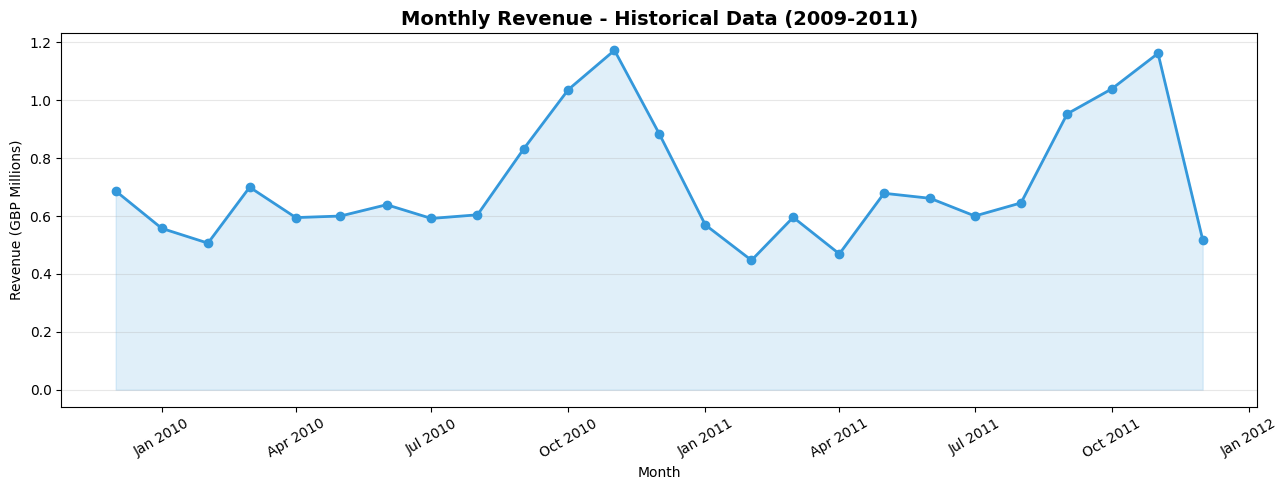

Saved: raw_monthly_sales.png


In [4]:
plt.figure(figsize=(13, 5))
plt.plot(monthly["ds"], monthly["y"] / 1e6, marker="o",
         color="#3498db", linewidth=2, markersize=6)
plt.fill_between(monthly["ds"], monthly["y"] / 1e6,
                 alpha=0.15, color="#3498db")
plt.title("Monthly Revenue - Historical Data (2009-2011)",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (GBP Millions)")
plt.xticks(rotation=30)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMG + "raw_monthly_sales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: raw_monthly_sales.png")

In [5]:
TEST_MONTHS = 3

train = monthly.iloc[:-TEST_MONTHS].copy()
test  = monthly.iloc[-TEST_MONTHS:].copy()

print(f"Training set : {len(train)} months ({train['ds'].min().strftime('%b %Y')} to {train['ds'].max().strftime('%b %Y')})")
print(f"Test set     : {len(test)} months ({test['ds'].min().strftime('%b %Y')} to {test['ds'].max().strftime('%b %Y')})")

Training set : 22 months (Dec 2009 to Sep 2011)
Test set     : 3 months (Oct 2011 to Dec 2011)


In [6]:
model = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = False,           # monthly data - weekly not relevant
    daily_seasonality       = False,
    seasonality_mode        = "multiplicative", # better for retail (peaks scale with revenue)
    changepoint_prior_scale = 0.1,             # controls trend flexibility
    seasonality_prior_scale = 10,              # controls seasonality strength
    interval_width          = 0.95             # 95% confidence interval
)

model.add_seasonality(
    name          = "monthly",
    period        = 30.5,
    fourier_order = 5
)

model.fit(train)
print("Prophet model trained successfully")

06:13:31 - cmdstanpy - INFO - Chain [1] start processing
06:13:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully


In [7]:
future_test  = model.make_future_dataframe(periods=TEST_MONTHS, freq="MS")
forecast_all = model.predict(future_test)

test_forecast = forecast_all.tail(TEST_MONTHS)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
test_actual   = test[["ds", "y"]].reset_index(drop=True)
eval_df       = test_actual.merge(test_forecast, on="ds")

mae  = mean_absolute_error(eval_df["y"], eval_df["yhat"])
rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))
mape = (np.abs((eval_df["y"] - eval_df["yhat"]) / eval_df["y"]).mean()) * 100

print("=" * 45)
print("       MODEL EVALUATION - TEST SET")
print("=" * 45)
print(f"  MAE  : GBP {mae:>12,.2f}")
print(f"  RMSE : GBP {rmse:>12,.2f}")
print(f"  MAPE : {mape:>10.2f}%")
print("=" * 45)
print("\nPredicted vs Actual:")
for _, row in eval_df.iterrows():
    err = abs(row["y"] - row["yhat"]) / row["y"] * 100
    print(f"  {row['ds'].strftime('%b %Y')}  Actual: GBP {row['y']:>10,.0f}  "
          f"Predicted: GBP {row['yhat']:>10,.0f}  Error: {err:.1f}%")

       MODEL EVALUATION - TEST SET
  MAE  : GBP   258,879.23
  RMSE : GBP   325,416.07
  MAPE :      41.59%

Predicted vs Actual:
  Oct 2011  Actual: GBP  1,039,319  Predicted: GBP  1,121,100  Error: 7.9%
  Nov 2011  Actual: GBP  1,161,817  Predicted: GBP  1,322,717  Error: 13.8%
  Dec 2011  Actual: GBP    518,211  Predicted: GBP  1,052,168  Error: 103.0%


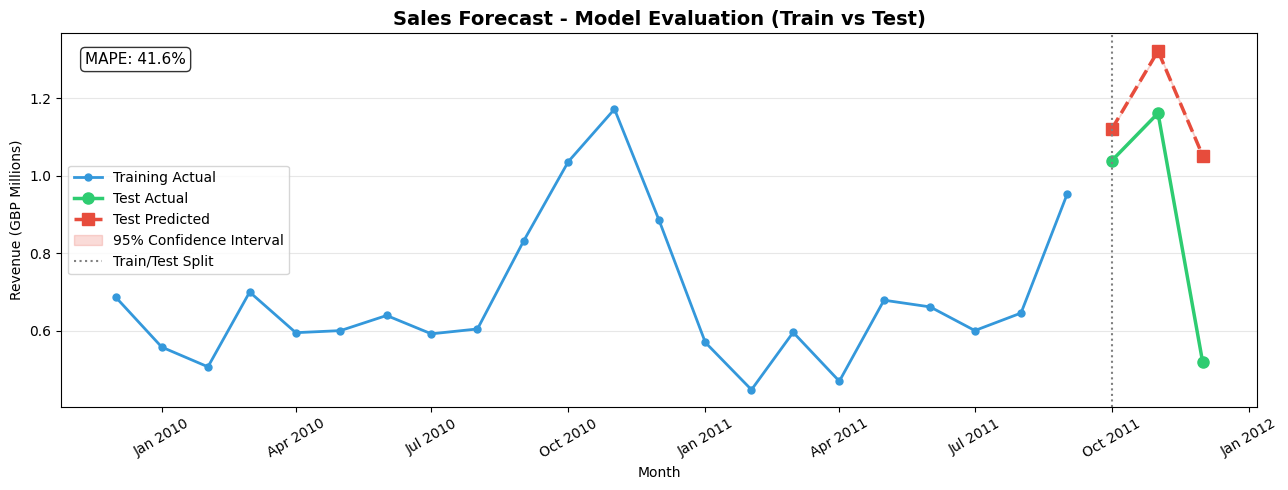

Saved: forecast_evaluation.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train["ds"], train["y"] / 1e6,
        color="#3498db", linewidth=2, marker="o", markersize=5,
        label="Training Actual")

ax.plot(test["ds"], test["y"] / 1e6,
        color="#2ecc71", linewidth=2.5, marker="o", markersize=8,
        label="Test Actual")

ax.plot(eval_df["ds"], eval_df["yhat"] / 1e6,
        color="#e74c3c", linewidth=2.5, marker="s", markersize=8,
        linestyle="--", label="Test Predicted")

ax.fill_between(eval_df["ds"],
                eval_df["yhat_lower"] / 1e6,
                eval_df["yhat_upper"] / 1e6,
                alpha=0.2, color="#e74c3c",
                label="95% Confidence Interval")

ax.axvline(test["ds"].min(), color="gray", linestyle=":",
           linewidth=1.5, label="Train/Test Split")

ax.text(0.02, 0.95, f"MAPE: {mape:.1f}%",
        transform=ax.transAxes, fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_title("Sales Forecast - Model Evaluation (Train vs Test)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (GBP Millions)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + "forecast_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: forecast_evaluation.png")

In [9]:
FORECAST_MONTHS = 6

final_model = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = False,
    daily_seasonality       = False,
    seasonality_mode        = "multiplicative",
    changepoint_prior_scale = 0.1,
    seasonality_prior_scale = 10,
    interval_width          = 0.95
)
final_model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
final_model.fit(monthly)

future   = final_model.make_future_dataframe(periods=FORECAST_MONTHS, freq="MS")
forecast = final_model.predict(future)

historical_forecast = forecast[forecast["ds"] <= monthly["ds"].max()]
future_forecast     = forecast[forecast["ds"] >  monthly["ds"].max()]

print(f"Forecast generated for {FORECAST_MONTHS} months ahead")
print(f"\nNext {FORECAST_MONTHS} months forecast:")
print("-" * 65)
for _, row in future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].iterrows():
    print(f"  {row['ds'].strftime('%b %Y')}  "
          f"Predicted: GBP {row['yhat']:>10,.0f}  "
          f"Range: GBP {row['yhat_lower']:>10,.0f} to GBP {row['yhat_upper']:>10,.0f}")
print("-" * 65)

06:13:38 - cmdstanpy - INFO - Chain [1] start processing
06:13:46 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated for 6 months ahead

Next 6 months forecast:
-----------------------------------------------------------------
  Jan 2012  Predicted: GBP    418,388  Range: GBP    418,107 to GBP    418,637
  Feb 2012  Predicted: GBP  1,216,510  Range: GBP  1,214,022 to GBP  1,218,747
  Mar 2012  Predicted: GBP  2,194,446  Range: GBP  2,186,538 to GBP  2,202,073
  Apr 2012  Predicted: GBP  1,041,489  Range: GBP  1,035,886 to GBP  1,046,724
  May 2012  Predicted: GBP  1,108,017  Range: GBP  1,100,064 to GBP  1,115,958
  Jun 2012  Predicted: GBP    505,926  Range: GBP    501,229 to GBP    510,694
-----------------------------------------------------------------


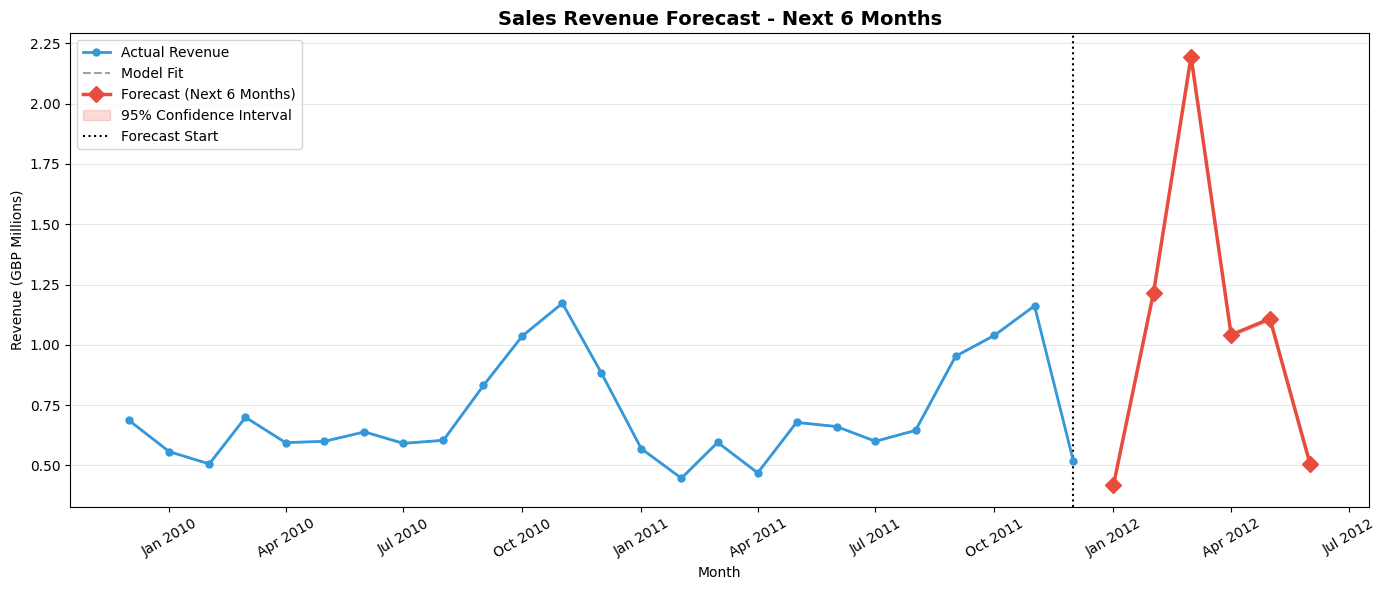

Saved: sales_forecast_6months.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly["ds"], monthly["y"] / 1e6,
        color="#3498db", linewidth=2, marker="o", markersize=5,
        label="Actual Revenue", zorder=3)

ax.plot(historical_forecast["ds"], historical_forecast["yhat"] / 1e6,
        color="#95a5a6", linewidth=1.5, linestyle="--",
        label="Model Fit", zorder=2)

ax.fill_between(historical_forecast["ds"],
                historical_forecast["yhat_lower"] / 1e6,
                historical_forecast["yhat_upper"] / 1e6,
                alpha=0.1, color="#3498db")

ax.plot(future_forecast["ds"], future_forecast["yhat"] / 1e6,
        color="#e74c3c", linewidth=2.5, marker="D", markersize=8,
        label=f"Forecast (Next {FORECAST_MONTHS} Months)", zorder=3)

ax.fill_between(future_forecast["ds"],
                future_forecast["yhat_lower"] / 1e6,
                future_forecast["yhat_upper"] / 1e6,
                alpha=0.2, color="#e74c3c",
                label="95% Confidence Interval")

ax.axvline(monthly["ds"].max(), color="black", linestyle=":",
           linewidth=1.5, label="Forecast Start")

ax.set_title(f"Sales Revenue Forecast - Next {FORECAST_MONTHS} Months",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (GBP Millions)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + "sales_forecast_6months.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sales_forecast_6months.png")

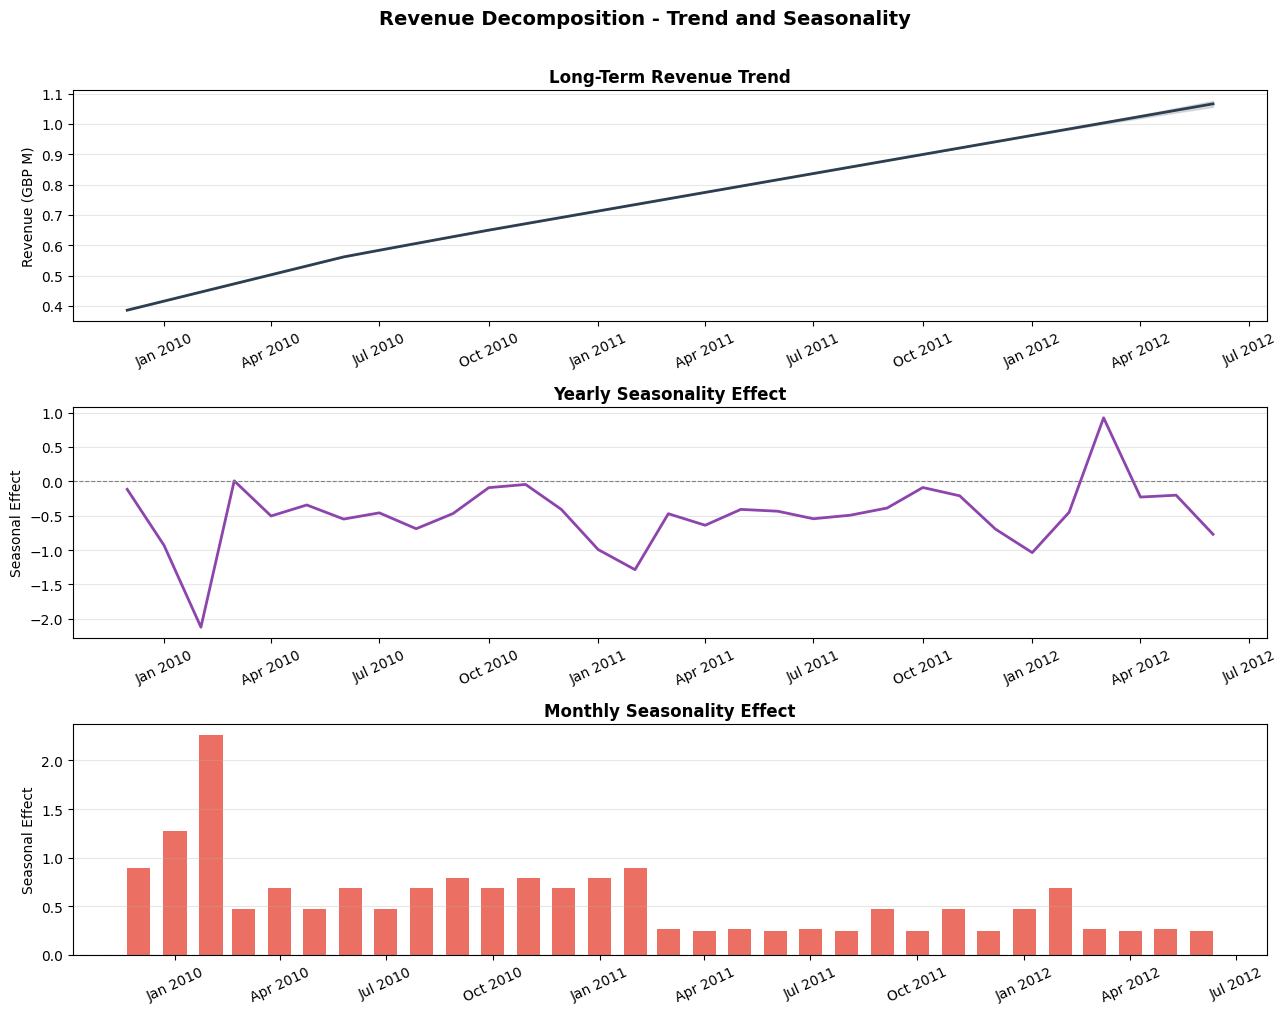

Saved: forecast_decomposition.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(forecast["ds"], forecast["trend"] / 1e6,
             color="#2c3e50", linewidth=2)
axes[0].fill_between(forecast["ds"],
                     forecast["trend_lower"] / 1e6,
                     forecast["trend_upper"] / 1e6,
                     alpha=0.15, color="#2c3e50")
axes[0].set_title("Long-Term Revenue Trend", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Revenue (GBP M)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

if "yearly" in forecast.columns:
    axes[1].plot(forecast["ds"], forecast["yearly"],
                 color="#8e44ad", linewidth=2)
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_title("Yearly Seasonality Effect", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Seasonal Effect")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

if "monthly" in forecast.columns:
    bar_colors = ["#e74c3c" if v > 0 else "#3498db" for v in forecast["monthly"]]
    axes[2].bar(forecast["ds"], forecast["monthly"],
                color=bar_colors, width=20, alpha=0.8)
    axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[2].set_title("Monthly Seasonality Effect", fontsize=12, fontweight="bold")
    axes[2].set_ylabel("Seasonal Effect")
    axes[2].grid(axis="y", alpha=0.3)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.setp([a.get_xticklabels() for a in axes], rotation=25)
plt.suptitle("Revenue Decomposition - Trend and Seasonality",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(IMG + "forecast_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: forecast_decomposition.png")

Peak revenue month   : Nov
Lowest revenue month : Feb


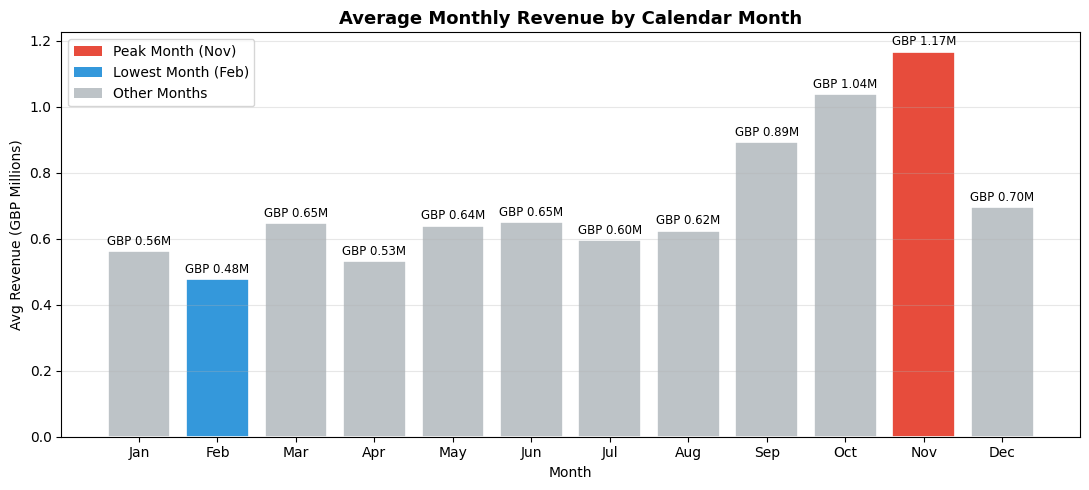

Saved: seasonal_pattern.png


In [12]:
monthly["month_num"]  = monthly["ds"].dt.month
monthly["month_name"] = monthly["ds"].dt.strftime("%b")

monthly_avg = monthly.groupby(["month_num", "month_name"])["y"].mean().reset_index()
monthly_avg = monthly_avg.sort_values("month_num")

peak_month   = monthly_avg.loc[monthly_avg["y"].idxmax(), "month_name"]
lowest_month = monthly_avg.loc[monthly_avg["y"].idxmin(), "month_name"]

print(f"Peak revenue month   : {peak_month}")
print(f"Lowest revenue month : {lowest_month}")

fig, ax = plt.subplots(figsize=(11, 5))
colors = [
    "#e74c3c" if m == peak_month
    else "#3498db" if m == lowest_month
    else "#bdc3c7"
    for m in monthly_avg["month_name"]
]
bars = ax.bar(monthly_avg["month_name"], monthly_avg["y"] / 1e6,
              color=colors, edgecolor="white", linewidth=1.2)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"GBP {bar.get_height():.2f}M",
            ha="center", va="bottom", fontsize=8.5)

legend_elements = [
    Patch(facecolor="#e74c3c", label=f"Peak Month ({peak_month})"),
    Patch(facecolor="#3498db", label=f"Lowest Month ({lowest_month})"),
    Patch(facecolor="#bdc3c7", label="Other Months")
]
ax.legend(handles=legend_elements)
ax.set_title("Average Monthly Revenue by Calendar Month",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Revenue (GBP Millions)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + "seasonal_pattern.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: seasonal_pattern.png")

In [13]:
monthly["year"] = monthly["ds"].dt.year
yoy = monthly.groupby("year")["y"].sum().reset_index()
yoy.columns = ["Year", "Total_Revenue"]
yoy["YoY_Growth_%"] = yoy["Total_Revenue"].pct_change() * 100

print("Year-over-Year Revenue Summary:")
print("=" * 50)
for _, row in yoy.iterrows():
    growth_str = f"{row['YoY_Growth_%']:+.1f}%" if not pd.isna(row["YoY_Growth_%"]) else "baseline"
    print(f"  {int(row['Year'])}  Revenue: GBP {row['Total_Revenue']:>12,.0f}   Growth: {growth_str}")
print("=" * 50)

Year-over-Year Revenue Summary:
  2009  Revenue: GBP      686,654   Growth: baseline
  2010  Revenue: GBP    8,718,063   Growth: +1169.6%
  2011  Revenue: GBP    8,338,712   Growth: -4.4%


In [14]:
df_cv = cross_validation(
    final_model,
    initial  = "456 days",
    period   = "30 days",
    horizon  = "90 days",
    parallel = None
)

df_perf = performance_metrics(df_cv)

print("Cross-Validation Performance Metrics:")
print("-" * 55)
print(df_perf[["horizon", "mae", "rmse", "mape"]].to_string(index=False))
print("-" * 55)

  0%|                                                     | 0/7 [00:00<?, ?it/s]06:13:47 - cmdstanpy - INFO - Chain [1] start processing
06:13:53 - cmdstanpy - INFO - Chain [1] done processing
 14%|██████▍                                      | 1/7 [00:05<00:32,  5.46s/it]06:13:53 - cmdstanpy - INFO - Chain [1] start processing
06:13:58 - cmdstanpy - INFO - Chain [1] done processing
 29%|████████████▊                                | 2/7 [00:11<00:28,  5.65s/it]06:13:58 - cmdstanpy - INFO - Chain [1] start processing
06:14:04 - cmdstanpy - INFO - Chain [1] done processing
 43%|███████████████████▎                         | 3/7 [00:17<00:23,  5.80s/it]06:14:04 - cmdstanpy - INFO - Chain [1] start processing
06:14:11 - cmdstanpy - INFO - Chain [1] done processing
 57%|█████████████████████████▋                   | 4/7 [00:23<00:18,  6.06s/it]06:14:11 - cmdstanpy - INFO - Chain [1] start processing
06:14:12 - cmdstanpy - INFO - Chain [1] done processing
 71%|██████████████████████████████

Cross-Validation Performance Metrics:
-------------------------------------------------------
horizon          mae         rmse     mape
26 days 2.353304e+05 3.271556e+05 0.349442
27 days 3.517583e+05 3.526631e+05 0.557137
28 days 4.888351e+05 5.080044e+05 0.763513
29 days 7.596202e+04 7.618459e+04 0.076151
56 days 2.080418e+05 2.464618e+05 0.288683
57 days 3.316953e+05 4.008848e+05 0.509853
58 days 3.434085e+05 3.786952e+05 0.530068
59 days 2.623802e+06 3.693784e+06 2.752628
60 days 1.392351e+06 2.614377e+06 1.445559
87 days 5.575454e+05 5.718802e+05 0.895959
88 days 3.217198e+05 4.089161e+05 0.514529
89 days 2.646536e+05 3.253064e+05 0.274457
90 days 3.819234e+05 4.110714e+05 0.614128
-------------------------------------------------------


df_cv columns: ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'y', 'cutoff']


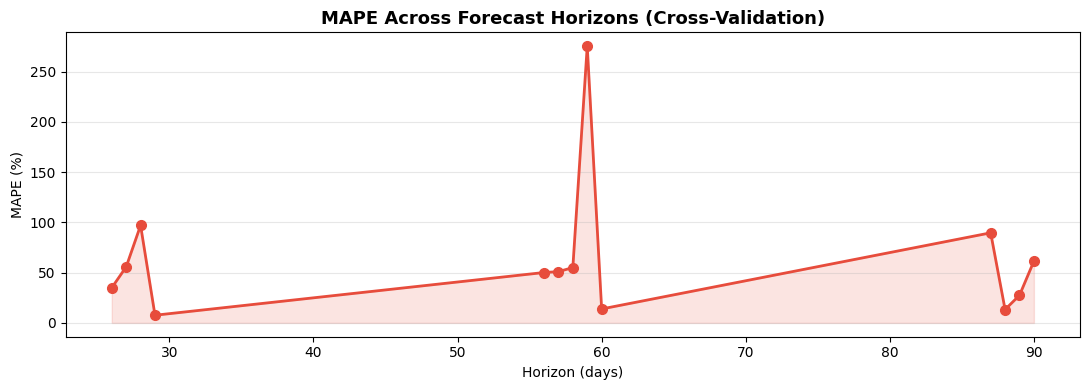

Saved: cross_validation_mape.png


In [15]:
print("df_cv columns:", df_cv.columns.tolist())

if "horizon" in df_cv.columns:
    df_cv["horizon_days"] = df_cv["horizon"].dt.days
elif "horizon_days" not in df_cv.columns:
    df_cv["horizon_days"] = (df_cv["ds"] - df_cv["cutoff"]).dt.days

mape_by_horizon = (
    df_cv
    .groupby("horizon_days")
    .apply(lambda g: (np.abs(g["y"] - g["yhat"]) / g["y"]).mean() * 100)
    .reset_index()
)
mape_by_horizon.columns = ["Horizon_days", "MAPE_pct"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    mape_by_horizon["Horizon_days"],
    mape_by_horizon["MAPE_pct"],
    marker="o", color="#e74c3c", linewidth=2, markersize=7
)
ax.fill_between(
    mape_by_horizon["Horizon_days"],
    mape_by_horizon["MAPE_pct"],
    alpha=0.15, color="#e74c3c"
)
ax.set_title("MAPE Across Forecast Horizons (Cross-Validation)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("MAPE (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + "cross_validation_mape.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cross_validation_mape.png")

In [16]:
forecast_export = future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_export.columns = ["Month", "Predicted_Revenue", "Lower_Bound", "Upper_Bound"]
forecast_export["Month"] = forecast_export["Month"].dt.strftime("%Y-%m")
forecast_export = forecast_export.round(2)
forecast_export.to_csv("../data/sales_forecast.csv", index=False)
print("Saved: sales_forecast.csv")

full_export = forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend"]].copy()
full_export.columns = ["Month", "Predicted_Revenue", "Lower_Bound", "Upper_Bound", "Trend"]
full_export["Month"] = full_export["Month"].dt.strftime("%Y-%m")
full_export = full_export.round(2)
full_export.to_csv("../data/sales_forecast_full.csv", index=False)
print("Saved: sales_forecast_full.csv")

monthly_avg.to_csv("../data/monthly_seasonality.csv", index=False)
print("Saved: monthly_seasonality.csv")

yoy.to_csv("../data/yoy_growth.csv", index=False)
print("Saved: yoy_growth.csv")

metrics = pd.DataFrame([{
    "MAE":  round(mae, 2),
    "RMSE": round(rmse, 2),
    "MAPE": round(mape, 2)
}])
metrics.to_csv("/home/adityaa/Desktop/Mini Project/data/forecast_metrics.csv", index=False)
print("Saved: forecast_metrics.csv")

joblib.dump(final_model, "/home/adityaa/Desktop/Mini Project/data/prophet_model.pkl")
print("Saved: prophet_model.pkl")

print("\nAll outputs saved. Ready for Flask dashboard.")

Saved: sales_forecast.csv
Saved: sales_forecast_full.csv
Saved: monthly_seasonality.csv
Saved: yoy_growth.csv
Saved: forecast_metrics.csv
Saved: prophet_model.pkl

All outputs saved. Ready for Flask dashboard.


In [17]:
print(metrics)

         MAE       RMSE   MAPE
0  258879.23  325416.07  41.59
